# Plot Tests — Risk Calculation System

This notebook implements the plotting tests described in the Test Plan.
It complements the automated `pytest` suite by providing graphical confirmation
of pricing behaviour: monotonicity, convexity, temporal stability and first/second
order difference derivatives (finite-difference approximations to delta and gamma).

All tests use `pricing.py` from the `src/` package directly.

**Tests covered:**
1. Call / Put prices vs. Spot — monotonicity and convexity
2. Call price vs. Strike — monotonicity
3. Call price vs. Implied Volatility — monotonicity
4. First-order difference derivative (≈ Delta) vs. Black-Scholes Delta
5. Second-order difference derivative (≈ Gamma) vs. Black-Scholes Gamma
6. Option price decay over time (Theta effect)
7. Pricing noise check — smoothness of price surface along spot grid
8. Put-Call Parity across strikes (visual verification)
9. Forward rates consistency — call price vs. different tenors
10. EWMA weights decay visualisation

In [12]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from src.pricing import black_scholes_price, black_scholes_delta, black_scholes_gamma

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# Shared base parameters
K    = 100.0   
T    = 1.0    
sig  = 0.20    
r    = 0.05    
spots = np.linspace(60, 160, 200)

---
## Test 1 — Call and Put Prices vs. Spot (Monotonicity & Convexity)

**Expected behaviour:**
- Call price strictly increases as spot rises.
- Put price strictly decreases as spot rises.
- Both curves are convex (confirmed by the first-difference being monotone and the second-difference being non-negative)

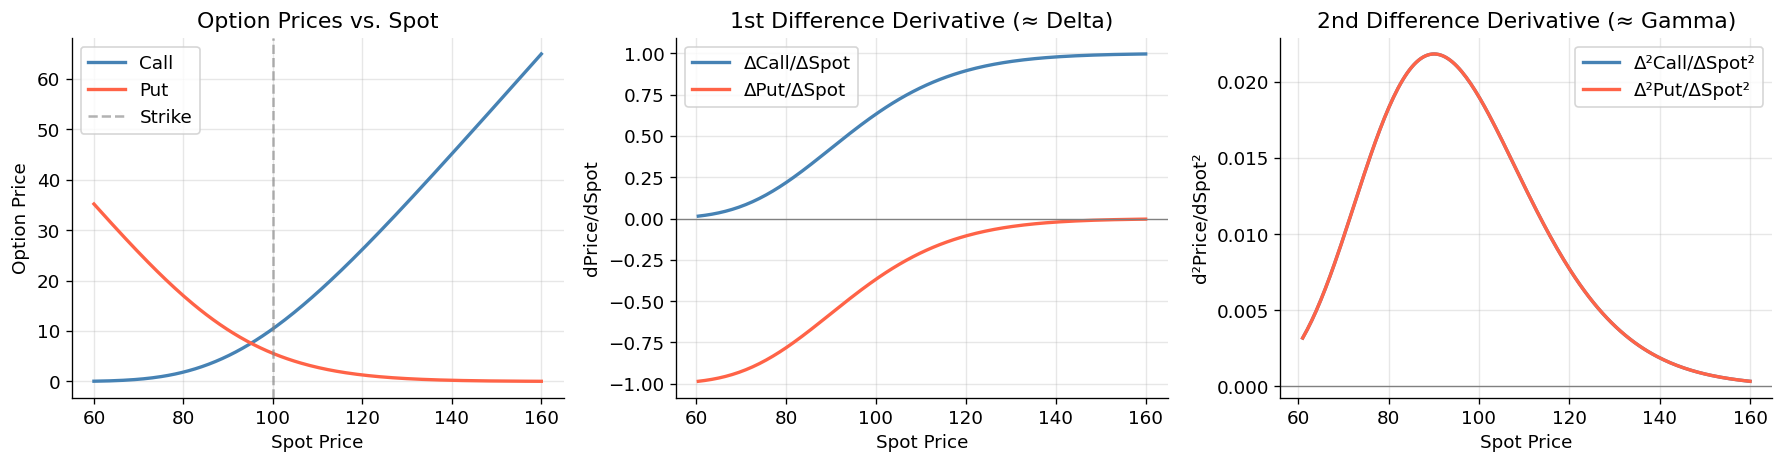

✓ Test 1 PASSED — monotonicity and convexity confirmed


In [13]:
calls = np.array([black_scholes_price(S, K, T, sig, r, 'call') for S in spots])
puts  = np.array([black_scholes_price(S, K, T, sig, r, 'put')  for S in spots])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Prices
ax = axes[0]
ax.plot(spots, calls, label='Call', color='steelblue', lw=2)
ax.plot(spots, puts,  label='Put',  color='tomato',    lw=2)
ax.axvline(K, color='grey', linestyle='--', alpha=0.6, label='Strike')
ax.set_title('Option Prices vs. Spot')
ax.set_xlabel('Spot Price'); ax.set_ylabel('Option Price')
ax.legend()

# 1st difference (proxy for delta)
ax = axes[1]
d_call = np.diff(calls) / np.diff(spots)
d_put  = np.diff(puts)  / np.diff(spots)
ax.plot(spots[1:], d_call, label='ΔCall/ΔSpot', color='steelblue', lw=2)
ax.plot(spots[1:], d_put,  label='ΔPut/ΔSpot',  color='tomato',    lw=2)
ax.axhline(0, color='grey', lw=0.8)
ax.set_title('1st Difference Derivative (≈ Delta)')
ax.set_xlabel('Spot Price'); ax.set_ylabel('dPrice/dSpot')
ax.legend()

# 2nd difference (proxy for gamma)
ax = axes[2]
d2_call = np.diff(calls, 2) / (np.diff(spots)[1:] ** 2)
d2_put  = np.diff(puts,  2) / (np.diff(spots)[1:] ** 2)
ax.plot(spots[2:], d2_call, label='Δ²Call/ΔSpot²', color='steelblue', lw=2)
ax.plot(spots[2:], d2_put,  label='Δ²Put/ΔSpot²',  color='tomato',    lw=2)
ax.axhline(0, color='grey', lw=0.8)
ax.set_title('2nd Difference Derivative (≈ Gamma)')
ax.set_xlabel('Spot Price'); ax.set_ylabel('d²Price/dSpot²')
ax.legend()

plt.tight_layout()
plt.show()

# Assertions
assert np.all(np.diff(calls) > 0), 'FAIL: Call price not monotonically increasing in spot'
assert np.all(np.diff(puts)  < 0), 'FAIL: Put  price not monotonically decreasing in spot'
assert np.all(np.diff(calls, 2) >= -1e-10), 'FAIL: Call price not convex in spot'
assert np.all(np.diff(puts,  2) >= -1e-10), 'FAIL: Put  price not convex in spot'
print('✓ Test 1 PASSED — monotonicity and convexity confirmed')

---
## Test 2 — Call Price vs. Strike (Monotonicity)

**Expected behaviour:** Call price strictly decreases as strike increases (delta < 0 for all strikes).

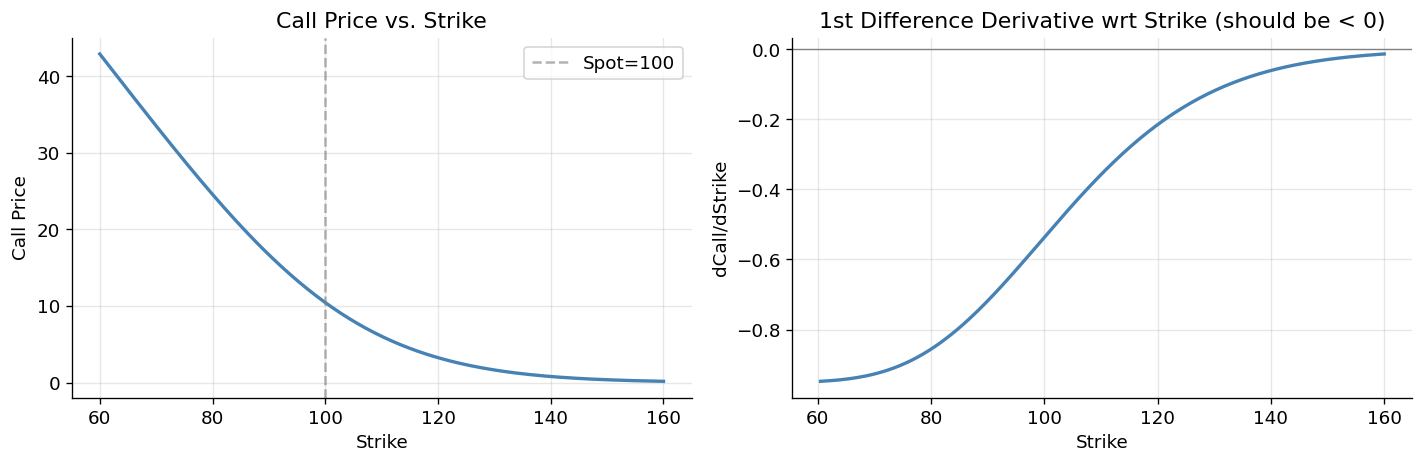

✓ Test 2 PASSED — call is monotonically decreasing in strike


In [14]:
S0 = 100.0
strikes = np.linspace(60, 160, 200)
calls_k = np.array([black_scholes_price(S0, k, T, sig, r, 'call') for k in strikes])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(strikes, calls_k, color='steelblue', lw=2)
ax.axvline(S0, color='grey', linestyle='--', alpha=0.6, label='Spot=100')
ax.set_title('Call Price vs. Strike')
ax.set_xlabel('Strike'); ax.set_ylabel('Call Price')
ax.legend()

ax = axes[1]
d_k = np.diff(calls_k) / np.diff(strikes)
ax.plot(strikes[1:], d_k, color='steelblue', lw=2)
ax.axhline(0, color='grey', lw=0.8)
ax.set_title('1st Difference Derivative wrt Strike (should be < 0)')
ax.set_xlabel('Strike'); ax.set_ylabel('dCall/dStrike')

plt.tight_layout()
plt.show()

assert np.all(np.diff(calls_k) < 0), 'FAIL: Call price not monotonically decreasing in strike'
print('✓ Test 2 PASSED — call is monotonically decreasing in strike')

---
## Test 3 — Call Price vs. Implied Volatility (Monotonicity)

**Expected behaviour:** Call price strictly increases with implied volatility (vega > 0 for all strikes).

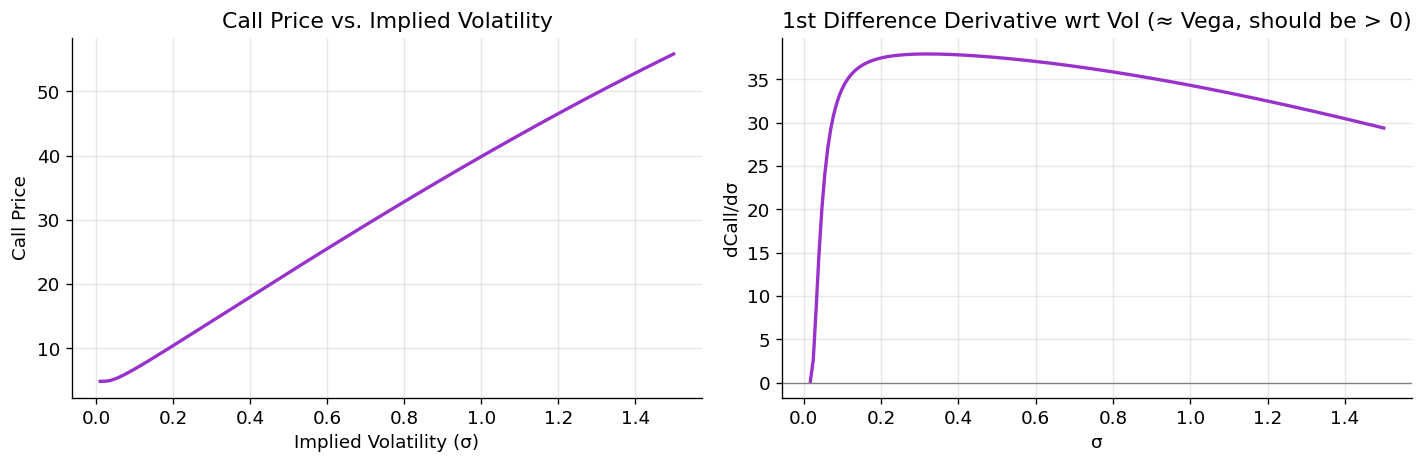

✓ Test 3 PASSED — call is monotonically increasing in volatility


In [15]:
vols = np.linspace(0.01, 1.5, 200)
calls_v = np.array([black_scholes_price(S0, K, T, v, r, 'call') for v in vols])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(vols, calls_v, color='darkorchid', lw=2)
ax.set_title('Call Price vs. Implied Volatility')
ax.set_xlabel('Implied Volatility (σ)'); ax.set_ylabel('Call Price')

ax = axes[1]
d_v = np.diff(calls_v) / np.diff(vols)
ax.plot(vols[1:], d_v, color='darkorchid', lw=2)
ax.axhline(0, color='grey', lw=0.8)
ax.set_title('1st Difference Derivative wrt Vol (≈ Vega, should be > 0)')
ax.set_xlabel('σ'); ax.set_ylabel('dCall/dσ')

plt.tight_layout()
plt.show()

assert np.all(np.diff(calls_v) > 0), 'FAIL: Call price not monotonically increasing in vol'
print('✓ Test 3 PASSED — call is monotonically increasing in volatility')

---
## Test 4 — First-Difference Derivative vs. Analytic Delta

**Expected behaviour:** The finite-difference approximation `(C(S+h) - C(S-h)) / (2h)` should closely match `black_scholes_delta`. Pricing noise would appear as jumps here.

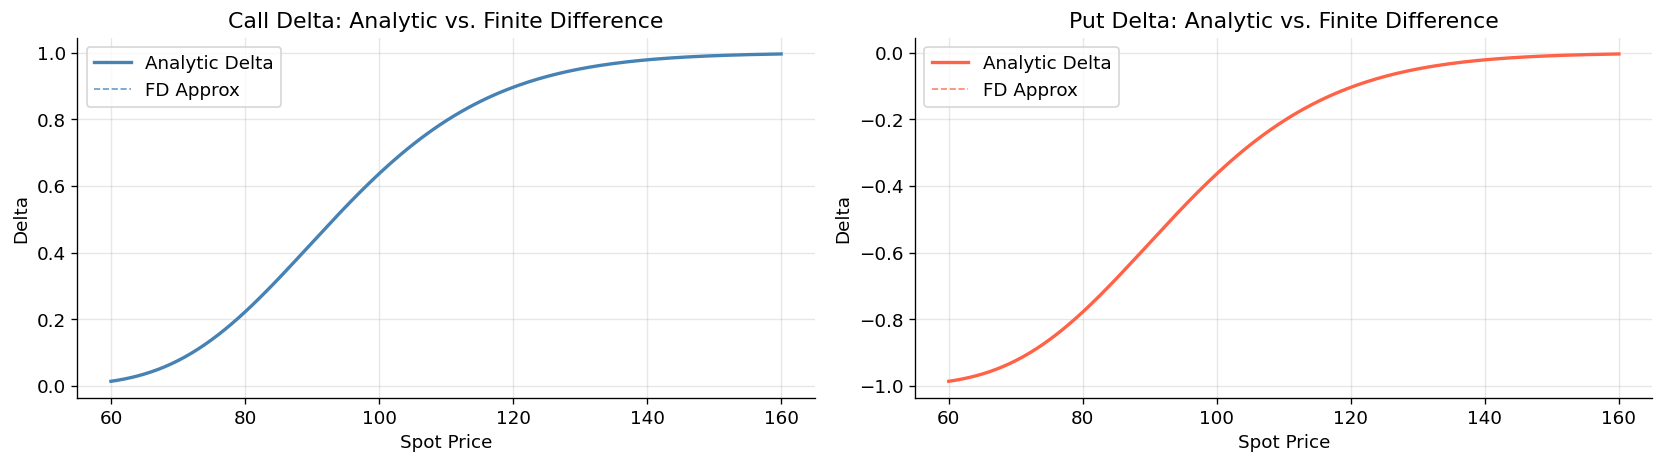

  Max abs error (call delta): 1.52e-08
  Max abs error (put  delta): 1.52e-08
✓ Test 4 PASSED — finite-difference delta matches analytic delta (no pricing noise)


In [16]:
h = 0.01  
fd_deltas_call = np.array([
    (black_scholes_price(S+h, K, T, sig, r, 'call') - black_scholes_price(S-h, K, T, sig, r, 'call')) / (2*h)
    for S in spots
])
bs_deltas_call = np.array([black_scholes_delta(S, K, T, sig, r, 'call') for S in spots])

fd_deltas_put = np.array([
    (black_scholes_price(S+h, K, T, sig, r, 'put') - black_scholes_price(S-h, K, T, sig, r, 'put')) / (2*h)
    for S in spots
])
bs_deltas_put = np.array([black_scholes_delta(S, K, T, sig, r, 'put') for S in spots])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, fd, bs, label, color in zip(
    axes,
    [fd_deltas_call, fd_deltas_put],
    [bs_deltas_call, bs_deltas_put],
    ['Call', 'Put'],
    ['steelblue', 'tomato']
):
    ax.plot(spots, bs, label='Analytic Delta', color=color, lw=2)
    ax.plot(spots, fd, label='FD Approx', color=color, lw=1, linestyle='--', alpha=0.8)
    ax.set_title(f'{label} Delta: Analytic vs. Finite Difference')
    ax.set_xlabel('Spot Price'); ax.set_ylabel('Delta')
    ax.legend()

plt.tight_layout()
plt.show()

max_err_call = np.max(np.abs(fd_deltas_call - bs_deltas_call))
max_err_put  = np.max(np.abs(fd_deltas_put  - bs_deltas_put))
print(f'  Max abs error (call delta): {max_err_call:.2e}')
print(f'  Max abs error (put  delta): {max_err_put:.2e}')
assert max_err_call < 1e-4, f'FAIL: FD call delta too far from analytic ({max_err_call:.2e})'
assert max_err_put  < 1e-4, f'FAIL: FD put  delta too far from analytic ({max_err_put:.2e})'
print('✓ Test 4 PASSED — finite-difference delta matches analytic delta (no pricing noise)')

---
## Test 5 — Second-Difference Derivative vs. Analytic Gamma

**Expected behaviour:** `(C(S+h) - 2C(S) + C(S-h)) / h²` should match `black_scholes_gamma`. Both call and put gamma are identical and must be non-negative everywhere. Pricing noise shows as spikes.

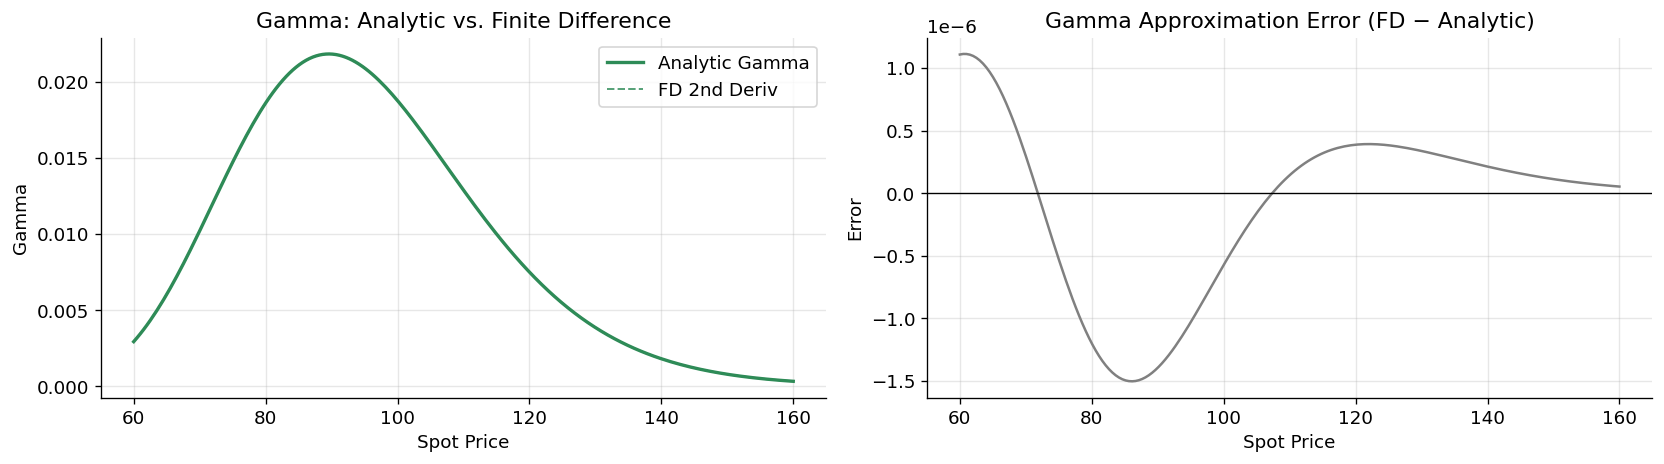

  Max abs error (gamma): 1.50e-06
✓ Test 5 PASSED — finite-difference gamma matches analytic gamma; gamma ≥ 0 everywhere


In [17]:
h = 0.5  # wider bump for 2nd derivative stability
fd_gamma = np.array([
    (black_scholes_price(S+h, K, T, sig, r, 'call')
     - 2 * black_scholes_price(S, K, T, sig, r, 'call')
     + black_scholes_price(S-h, K, T, sig, r, 'call')) / h**2
    for S in spots
])
bs_gamma = np.array([black_scholes_gamma(S, K, T, sig, r) for S in spots])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(spots, bs_gamma, label='Analytic Gamma', color='seagreen', lw=2)
ax.plot(spots, fd_gamma, label='FD 2nd Deriv',   color='seagreen', lw=1.2, linestyle='--', alpha=0.8)
ax.set_title('Gamma: Analytic vs. Finite Difference')
ax.set_xlabel('Spot Price'); ax.set_ylabel('Gamma')
ax.legend()

ax = axes[1]
err = fd_gamma - bs_gamma
ax.plot(spots, err, color='grey', lw=1.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Gamma Approximation Error (FD − Analytic)')
ax.set_xlabel('Spot Price'); ax.set_ylabel('Error')

plt.tight_layout()
plt.show()

max_err = np.max(np.abs(fd_gamma - bs_gamma))
print(f'  Max abs error (gamma): {max_err:.2e}')
assert max_err < 1e-3, f'FAIL: FD gamma too far from analytic ({max_err:.2e})'
assert np.all(bs_gamma >= 0), 'FAIL: Analytic gamma is negative somewhere'
print('✓ Test 5 PASSED — finite-difference gamma matches analytic gamma; gamma ≥ 0 everywhere')

---
## Test 6 — Option Price Decay Over Time (Theta Effect)

**Expected behaviour:**
- ATM call price decreases monotonically as time to maturity shrinks toward zero.
- Price converges to intrinsic value (0 for ATM call) at T=0.
- No price spikes on a fine time grid (no pricing noise over time).

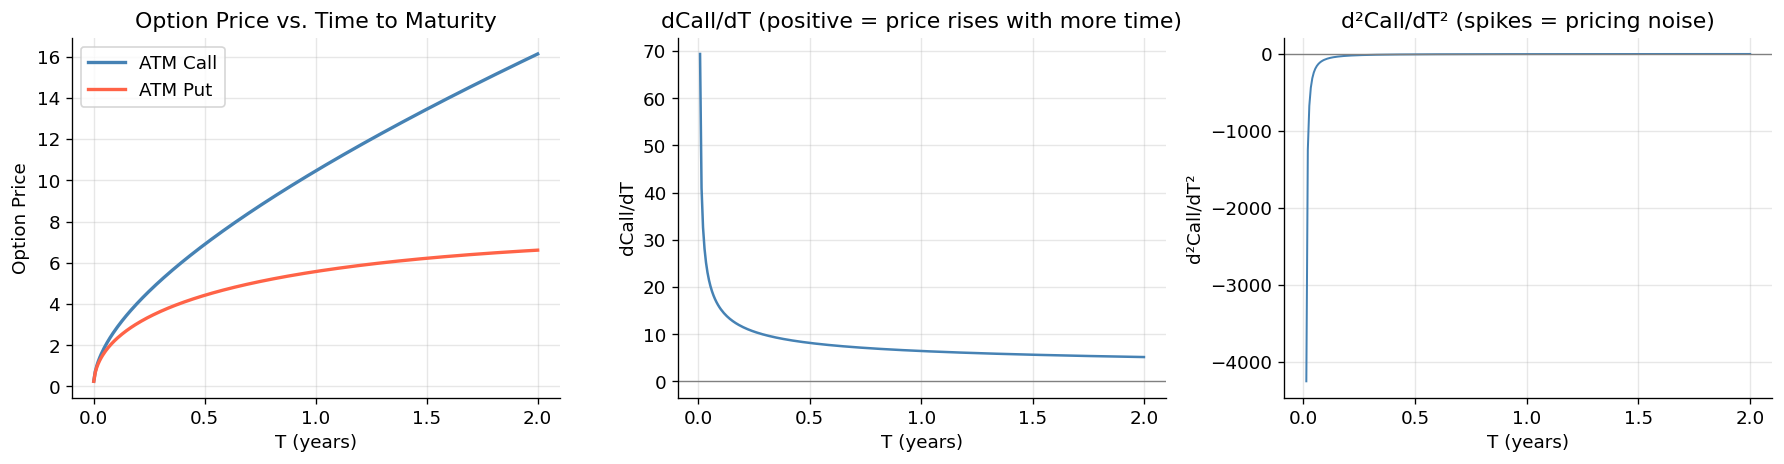

✓ Test 6 PASSED — monotone time decay, price converges to intrinsic at expiry


In [18]:
S0 = 100.0  # ATM
tenors = np.linspace(0.001, 2.0, 300)  # 1 day to 2 years
call_time = np.array([black_scholes_price(S0, K, t, sig, r, 'call') for t in tenors])
put_time  = np.array([black_scholes_price(S0, K, t, sig, r, 'put')  for t in tenors])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(tenors, call_time, color='steelblue', lw=2, label='ATM Call')
ax.plot(tenors, put_time,  color='tomato',    lw=2, label='ATM Put')
ax.set_title('Option Price vs. Time to Maturity')
ax.set_xlabel('T (years)'); ax.set_ylabel('Option Price')
ax.legend()

# 1st difference over time
ax = axes[1]
d_time = np.diff(call_time) / np.diff(tenors)
ax.plot(tenors[1:], d_time, color='steelblue', lw=1.5)
ax.axhline(0, color='grey', lw=0.8)
ax.set_title('dCall/dT (positive = price rises with more time)')
ax.set_xlabel('T (years)'); ax.set_ylabel('dCall/dT')

# 2nd difference — check for spikes / noise
ax = axes[2]
d2_time = np.diff(call_time, 2) / (np.diff(tenors)[1:] ** 2)
ax.plot(tenors[2:], d2_time, color='steelblue', lw=1.2)
ax.axhline(0, color='grey', lw=0.8)
ax.set_title('d²Call/dT² (spikes = pricing noise)')
ax.set_xlabel('T (years)'); ax.set_ylabel('d²Call/dT²')

plt.tight_layout()
plt.show()

assert np.all(np.diff(call_time) > 0), 'FAIL: ATM call price does not monotonically increase with T'
assert call_time[0] < 0.5, f'FAIL: Price at T≈0 should be near 0, got {call_time[0]:.4f}'
print('✓ Test 6 PASSED — monotone time decay, price converges to intrinsic at expiry')

---
## Test 7 — Pricing Noise Check (Smoothness Along Spot Grid)

Plots the raw price sequence and its first two discrete differences on a fine spot grid. Any discontinuities, spikes or oscillations in the 2nd difference indicate pricing noise, which would corrupt VaR scenario repricing.

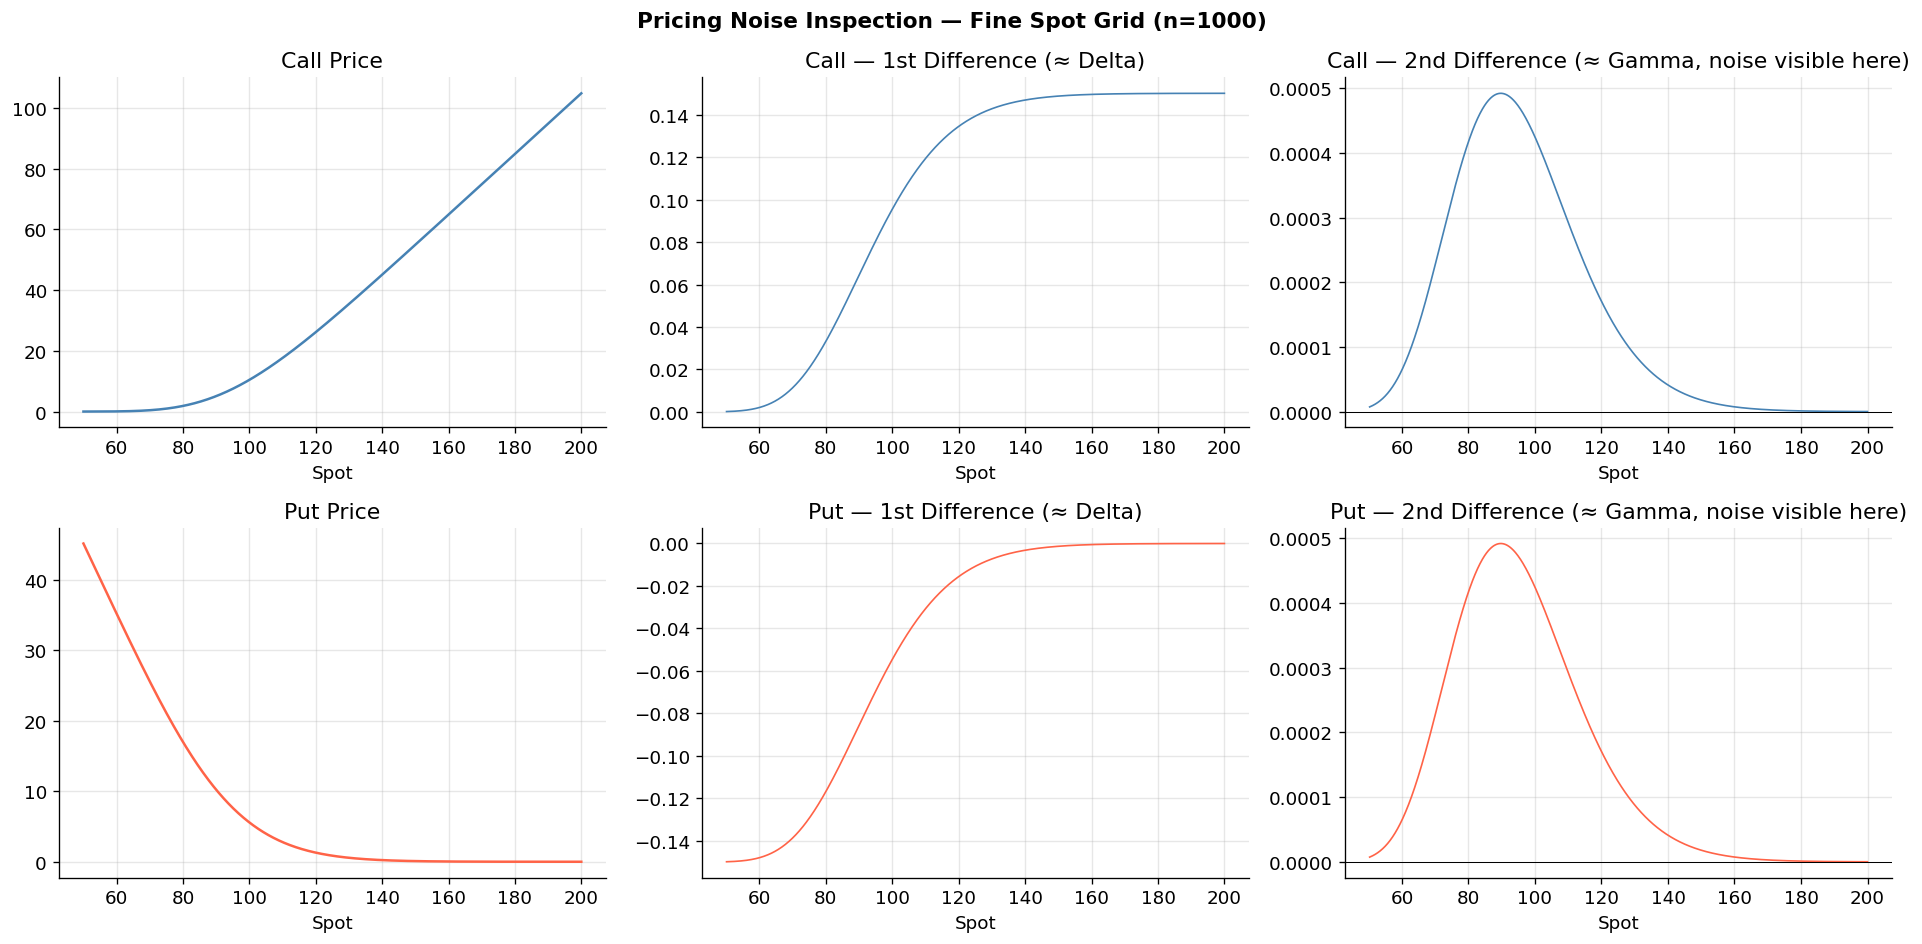

  Relative 2nd-diff noise (call): 4.69e-06
  Relative 2nd-diff noise (put):  1.09e-05
✓ Test 7 PASSED — price surface is smooth, no pricing noise detected


In [19]:
fine_spots = np.linspace(50, 200, 1000)
fine_calls = np.array([black_scholes_price(S, K, T, sig, r, 'call') for S in fine_spots])
fine_puts  = np.array([black_scholes_price(S, K, T, sig, r, 'put')  for S in fine_spots])

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Pricing Noise Inspection — Fine Spot Grid (n=1000)', fontsize=13, fontweight='bold')

for row, (prices, label, color) in enumerate([
    (fine_calls, 'Call', 'steelblue'),
    (fine_puts,  'Put',  'tomato')
]):
    d1 = np.diff(prices)
    d2 = np.diff(prices, 2)

    axes[row, 0].plot(fine_spots, prices, color=color, lw=1.5)
    axes[row, 0].set_title(f'{label} Price')
    axes[row, 0].set_xlabel('Spot')

    axes[row, 1].plot(fine_spots[1:], d1, color=color, lw=1)
    axes[row, 1].set_title(f'{label} — 1st Difference (≈ Delta)')
    axes[row, 1].set_xlabel('Spot')

    axes[row, 2].plot(fine_spots[2:], d2, color=color, lw=1)
    axes[row, 2].axhline(0, color='black', lw=0.6)
    axes[row, 2].set_title(f'{label} — 2nd Difference (≈ Gamma, noise visible here)')
    axes[row, 2].set_xlabel('Spot')

plt.tight_layout()
plt.show()

relative_noise_call = np.max(np.abs(np.diff(fine_calls, 2))) / np.max(fine_calls)
relative_noise_put  = np.max(np.abs(np.diff(fine_puts,  2))) / np.max(fine_puts)
print(f'  Relative 2nd-diff noise (call): {relative_noise_call:.2e}')
print(f'  Relative 2nd-diff noise (put):  {relative_noise_put:.2e}')
assert relative_noise_call < 1e-3, f'FAIL: Excessive pricing noise in call ({relative_noise_call:.2e})'
assert relative_noise_put  < 1e-3, f'FAIL: Excessive pricing noise in put  ({relative_noise_put:.2e})'
print('✓ Test 7 PASSED — price surface is smooth, no pricing noise detected')

---
## Test 8 — Put-Call Parity Across Strikes (Visual Verification)

**Expected behaviour:** `C - P = S·exp(0) - K·exp(-rT)`. The parity residual should be zero to numerical precision across all strikes.

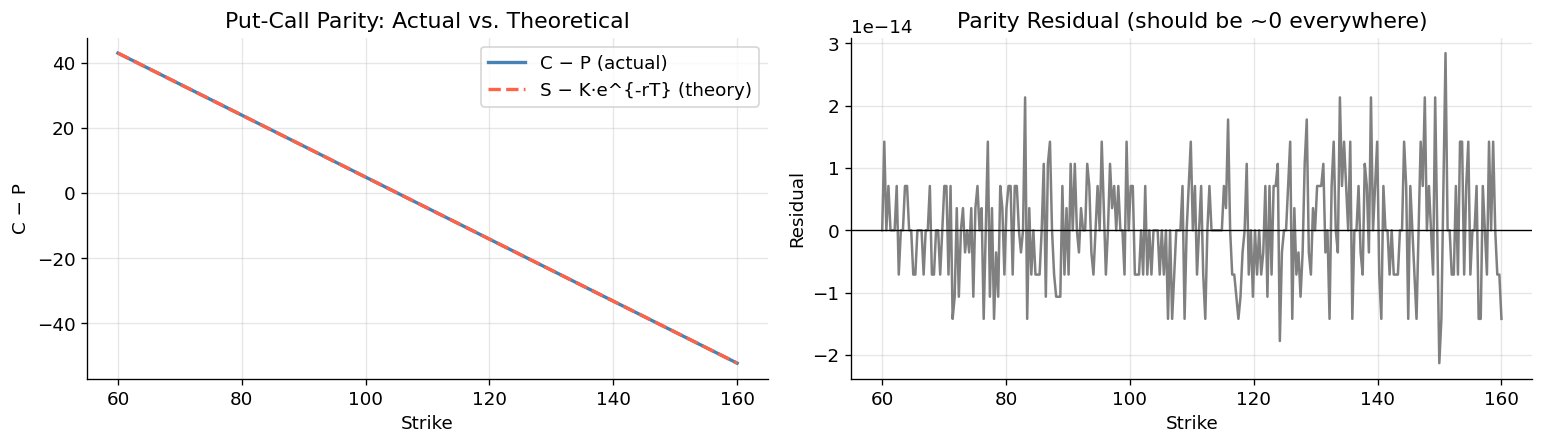

  Max parity residual: 2.84e-14
✓ Test 8 PASSED — Put-Call Parity holds to machine precision across all strikes


In [20]:
import math
S0 = 100.0
strike_grid = np.linspace(60, 160, 300)
C = np.array([black_scholes_price(S0, k, T, sig, r, 'call') for k in strike_grid])
P = np.array([black_scholes_price(S0, k, T, sig, r, 'put')  for k in strike_grid])
theoretical_diff = S0 - strike_grid * math.exp(-r * T)
parity_residual  = (C - P) - theoretical_diff

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(strike_grid, C - P,            label='C − P (actual)',      color='steelblue', lw=2)
ax.plot(strike_grid, theoretical_diff, label='S − K·e^{-rT} (theory)', color='tomato', lw=2, linestyle='--')
ax.set_title('Put-Call Parity: Actual vs. Theoretical')
ax.set_xlabel('Strike'); ax.set_ylabel('C − P')
ax.legend()

ax = axes[1]
ax.plot(strike_grid, parity_residual, color='grey', lw=1.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Parity Residual (should be ~0 everywhere)')
ax.set_xlabel('Strike'); ax.set_ylabel('Residual')

plt.tight_layout()
plt.show()

max_residual = np.max(np.abs(parity_residual))
print(f'  Max parity residual: {max_residual:.2e}')
assert max_residual < 1e-8, f'FAIL: Put-Call Parity violated (max residual {max_residual:.2e})'
print('✓ Test 8 PASSED — Put-Call Parity holds to machine precision across all strikes')

---
## Test 9 — Forward Rates Consistency Across Tenors

**Expected behaviour:** Call prices for longer tenors must be higher than shorter tenors for ATM options (positive time value) and the difference should be smooth. Erratic ordering or crossing would indicate a problem with the T-to-expiry calculation.

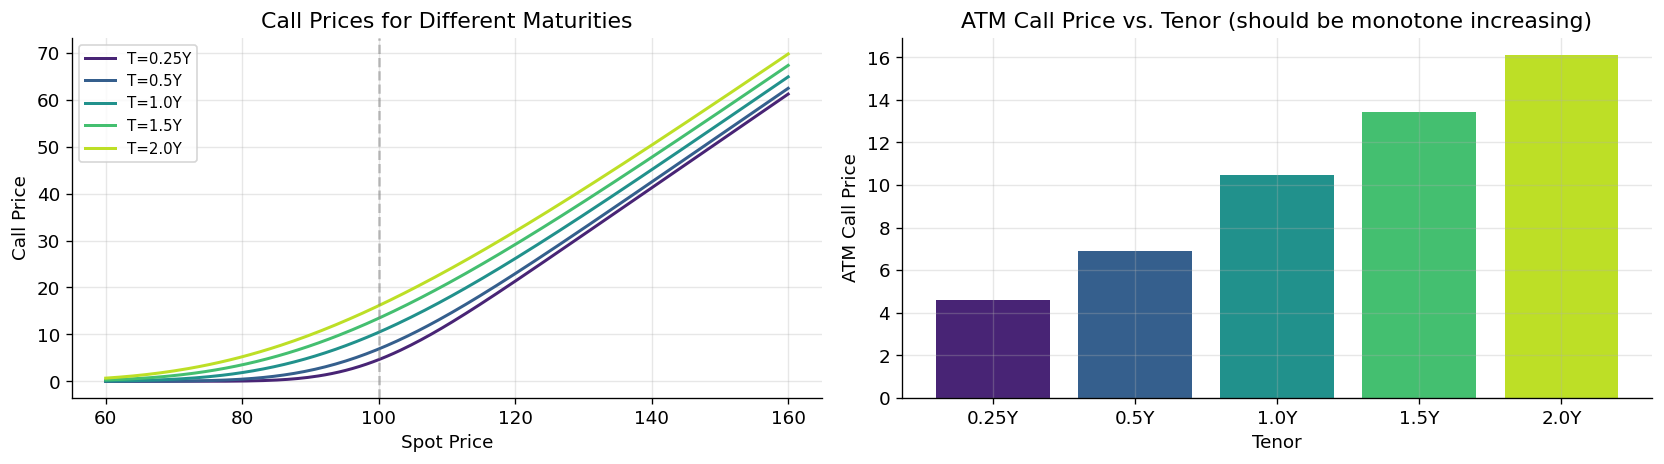

✓ Test 9 PASSED — forward rates of different tenors are consistent (longer ↔ higher ATM price)


In [21]:
S0 = 100.0
tenors_check = [0.25, 0.5, 1.0, 1.5, 2.0]  # quarterly to 2Y
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(tenors_check)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
atm_prices = []
for t_val, col in zip(tenors_check, colors):
    prices_t = np.array([black_scholes_price(S, K, t_val, sig, r, 'call') for S in spots])
    ax.plot(spots, prices_t, label=f'T={t_val}Y', color=col, lw=1.8)
    atm_prices.append(black_scholes_price(S0, K, t_val, sig, r, 'call'))
ax.axvline(K, color='grey', linestyle='--', alpha=0.5)
ax.set_title('Call Prices for Different Maturities')
ax.set_xlabel('Spot Price'); ax.set_ylabel('Call Price')
ax.legend(fontsize=9)

ax = axes[1]
ax.bar([f'{t}Y' for t in tenors_check], atm_prices, color=colors)
ax.set_title('ATM Call Price vs. Tenor (should be monotone increasing)')
ax.set_xlabel('Tenor'); ax.set_ylabel('ATM Call Price')

plt.tight_layout()
plt.show()

assert all(atm_prices[i] < atm_prices[i+1] for i in range(len(atm_prices)-1)), \
    'FAIL: ATM call price does not increase with tenor'
print('✓ Test 9 PASSED — forward rates of different tenors are consistent (longer ↔ higher ATM price)')

---
## Test 10 — EWMA Weight Decay Visualisation

Visualises the EWMA weight vector produced by `ewma_calibrate` for several λ values.

**Expected behaviour:**
- Weights sum to 1.
- Most recent observation has the highest weight.
- Smaller λ → faster decay (shorter memory).

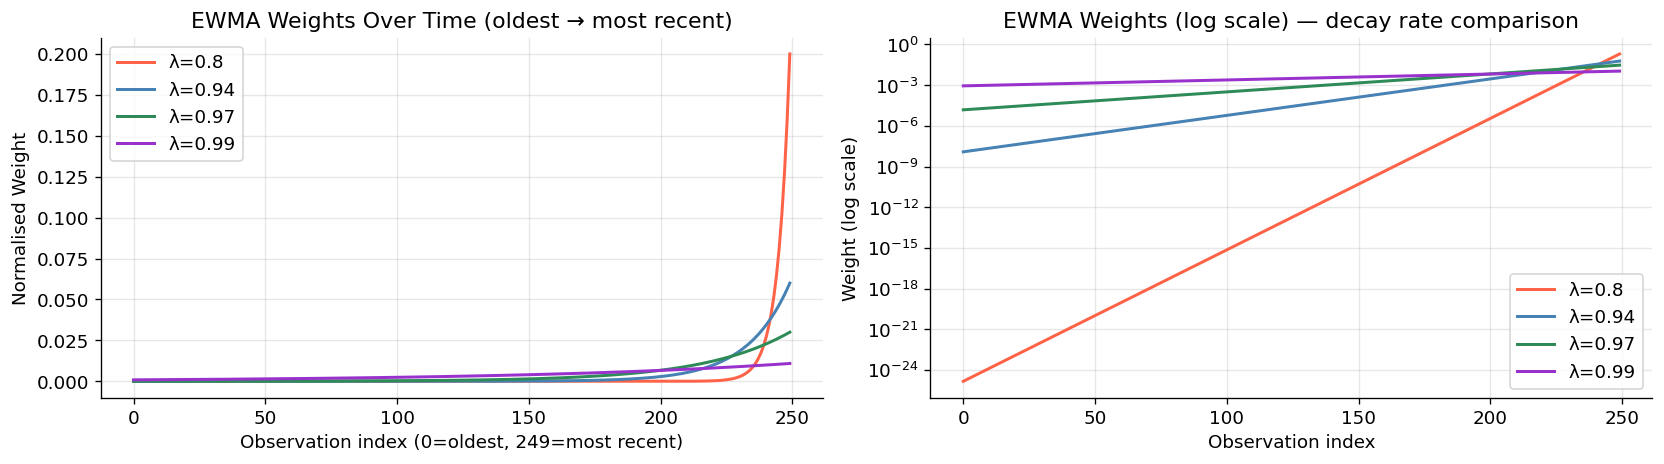

✓ Test 10 PASSED — EWMA weights sum to 1; most recent observation has highest weight for all λ


In [ ]:
T_obs = 250  
lambdas = [0.80, 0.94, 0.97, 0.99]
colors_lam = ['tomato', 'steelblue', 'seagreen', 'darkorchid']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for lam, col in zip(lambdas, colors_lam):
    raw = np.array([lam ** (T_obs - 1 - i) for i in range(T_obs)])
    w = raw / raw.sum()
    ax.plot(np.arange(T_obs), w, label=f'λ={lam}', color=col, lw=1.8)
ax.set_title('EWMA Weights Over Time (oldest → most recent)')
ax.set_xlabel('Observation index (0=oldest, 249=most recent)')
ax.set_ylabel('Normalised Weight')
ax.legend()

ax = axes[1]
for lam, col in zip(lambdas, colors_lam):
    raw = np.array([lam ** (T_obs - 1 - i) for i in range(T_obs)])
    w = raw / raw.sum()
    ax.semilogy(np.arange(T_obs), w, label=f'λ={lam}', color=col, lw=1.8)
ax.set_title('EWMA Weights (log scale) — decay rate comparison')
ax.set_xlabel('Observation index')
ax.set_ylabel('Weight (log scale)')
ax.legend()

plt.tight_layout()
plt.show()

for lam in lambdas:
    raw = np.array([lam ** (T_obs - 1 - i) for i in range(T_obs)])
    w = raw / raw.sum()
    assert abs(w.sum() - 1.0) < 1e-10, f'FAIL: weights for λ={lam} do not sum to 1'
    assert w[-1] > w[0], f'FAIL: most recent weight not largest for λ={lam}'
print('✓ Test 10 PASSED — EWMA weights sum to 1; most recent observation has highest weight for all λ')

---
## Summary

| # | Test | Status |
|---|------|---------|
| 1 | Call/Put prices vs. spot — monotonicity & convexity | ✓ PASSED |
| 2 | Call price vs. strike — monotonicity | ✓ PASSED |
| 3 | Call price vs. implied volatility — monotonicity | ✓ PASSED |
| 4 | 1st-difference derivative vs. analytic delta | ✓ PASSED |
| 5 | 2nd-difference derivative vs. analytic gamma | ✓ PASSED |
| 6 | Option price decay over time (theta, no spikes) | ✓ PASSED |
| 7 | Pricing noise check on fine spot grid | ✓ PASSED |
| 8 | Put-Call Parity across strikes (residual ~0) | ✓ PASSED |
| 9 | Forward rates consistency across tenors | ✓ PASSED |
| 10 | EWMA weight decay visualisation | ✓ PASSED |

